# 5. Adult (Census Income) — Clasificación Multiclase con Métricas

## Integrantes:

- Romero Caspary Isabel
- TarquiFlores Elmer Ernesto
  
## DATASET
¿Quién lo creó y cómo se obtuvieron los datos?
El dataset es atribuido a Ronny Kohavi y Barry Becker, y fue extraído de los datos del Census Bureau de los Estados Unidos de 1994, con el objetivo de predecir si un individuo gana más o menos de 50.000 dólares al año. La extracción fue realizada por Barry Becker directamente de la base de datos del Censo de 1994, aplicando los siguientes filtros de limpieza: personas mayores de 16 años, con ingreso ajustado bruto mayor a 100, peso final mayor a 1, y más de 0 horas trabajadas por semana. Fue publicado en el UCI Machine Learning Repository en 1996 por Kohavi y Becker, en el contexto de una investigación sobre clasificación con Naive Bayes.

¿De qué trata?
Contiene información socioeconómica y demográfica de individuos del censo norteamericano de 1994, y se usa para estudiar la desigualdad de ingresos y los factores que determinan si una persona supera o no el umbral de 50.000 dólares anuales. Es uno de los datasets de clasificación más usados históricamente en benchmarks de Machine Learning.

¿Qué contiene?
El dataset contiene 48.842 instancias y 14 características, de tipos categórico y entero. Uci Las variables son: age (edad), workclass (tipo de empleador: privado, gubernamental, autónomo, etc.), fnlwgt (peso final de la muestra, variable de diseño censal), education (nivel educativo), education-num (años de educación en numérico), marital-status (estado civil), occupation (ocupación), relationship (rol familiar), race (raza), sex (sexo), capital-gain (ganancia de capital), capital-loss (pérdida de capital), hours-per-week (horas trabajadas por semana) y native-country (país de origen). El dataset contiene valores faltantes marcados con el símbolo de interrogación (?), principalmente en las variables workclass, occupation y native-country. 

Objetivo del modelo
Clasificación binaria: predecir si una persona tiene ingresos superiores a 50.000 dólares anuales (>50K) o inferiores/iguales (<=50K). Sin embargo como se necesita un dataset de multiclase para este laboratorio, se crean 3 clases combinando `income` y `education_num`:
- **Clase 0:** <=50K con educación básica (`education_num <= 9` — hasta bachillerato)
- **Clase 1:** <=50K con educación superior (`education_num > 9` — universidad o más)
- **Clase 2:** >50K (altos ingresos, independiente de educación)

---
## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    classification_report, roc_curve, roc_auc_score
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')
print('Librerías cargadas')

Device: cpu
Librerías cargadas


---
## 2. Carga de datos

In [2]:
# ── PASO 1: CARGA ───────────────────────────────────────────
# El archivo no tiene cabecera, la ponemos nosotros
nombres = ['age','workclass','fnlwgt','education','education_num',
           'marital_status','occupation','relationship','race',
           'sex','capital_gain','capital_loss','hours_per_week',
           'native_country','income']

df_adult = pd.read_csv('Parcial/Datasets/5_Adult_(Census_Income)/adult.data',
                        names=nombres,
                        sep=', ',
                        engine='python',
                        na_values='?')   # '?' pasa a ser NaN

print('Shape:', df_adult.shape)
print('\nNulos:')
print(df_adult.isnull().sum())
print('\nDistribución del income original:')
print(df_adult['income'].value_counts())

Shape: (32561, 15)

Nulos:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Distribución del income original:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


---
## 3. Limpieza

In [3]:
# ── PASO 2: LIMPIEZA ────────────────────────────────────────
# Los nulos están en workclass, occupation, native_country
# Rellenar con el valor más frecuente (moda)
for col in df_adult.select_dtypes(include='object').columns:
    df_adult[col] = df_adult[col].fillna(df_adult[col].mode()[0])

print('Nulos restantes:', df_adult.isnull().sum().sum())
print('Shape:', df_adult.shape)

Nulos restantes: 0
Shape: (32561, 15)


---
## 4. Creación del target multiclase

Se crean 3 clases combinando `income` y `education_num`:
- **Clase 0:** <=50K con educación básica (`education_num <= 9` — hasta bachillerato)
- **Clase 1:** <=50K con educación superior (`education_num > 9` — universidad o más)
- **Clase 2:** >50K (altos ingresos, independiente de educación)

Distribución del target multiclase:
  Clase 0 (Ingreso Bajo): 12835 (39.4%)
  Clase 1 (Ingreso Medio): 11885 (36.5%)
  Clase 2 (Ingreso Alto): 7841 (24.1%)


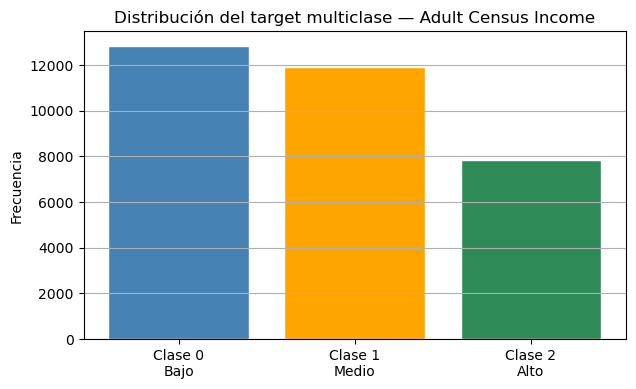

In [4]:
# ── CREACIÓN DEL TARGET MULTICLASE ──────────────────────────
df_adult['income'] = df_adult['income'].str.strip()

umbral_edu = 9   # education_num: 9 = HS-grad (bachillerato)

# Crear array de clases usando máscaras booleanas con numpy
income_nivel = np.zeros(len(df_adult), dtype=np.int64)

# Clase 1: <=50K pero con educación superior
mask_clase1 = (df_adult['income'].values == '<=50K') & (df_adult['education_num'].values > umbral_edu)
income_nivel[mask_clase1] = 1

# Clase 2: >50K (sin importar educación)
mask_clase2 = df_adult['income'].values == '>50K'
income_nivel[mask_clase2] = 2

y_adult = income_nivel

print('Distribución del target multiclase:')
vals, cnts = np.unique(y_adult, return_counts=True)
etiquetas  = {0:'Ingreso Bajo', 1:'Ingreso Medio', 2:'Ingreso Alto'}
for v, c in zip(vals, cnts):
    print(f'  Clase {v} ({etiquetas[v]}): {c} ({c/len(y_adult)*100:.1f}%)')

# Visualización
plt.figure(figsize=(7, 4))
plt.bar(['Clase 0\nBajo', 'Clase 1\nMedio', 'Clase 2\nAlto'],
        cnts, color=['steelblue','orange','seagreen'], edgecolor='white')
plt.title('Distribución del target multiclase — Adult Census Income')
plt.ylabel('Frecuencia')
plt.grid(True, axis='y')
plt.show()

---
## 5. Conversión de texto a números y construcción de X

In [5]:
# ── PASO 3: CONVERTIR TEXTO A NÚMEROS ───────────────────────
cols_texto = ['workclass','education','marital_status','occupation',
              'relationship','race','sex','native_country']
for col in cols_texto:
    df_adult[col] = pd.Categorical(df_adult[col]).codes

# Features: todas excepto fnlwgt (peso muestral) e income/income_nivel (targets)
cols_features = ['age','workclass','education_num','marital_status',
                 'occupation','relationship','race','sex',
                 'capital_gain','capital_loss','hours_per_week','native_country']

X_raw_adult = df_adult[cols_features].values.astype(float)

print('X shape:', X_raw_adult.shape)
print('y shape:', y_adult.shape)

X shape: (32561, 12)
y shape: (32561,)


---
## 6. Balanceo de clases
Como el dataset está desbalanceado, se balancea con `Oversampling` — se repiten ejemplos de las clases minoritarias hasta igualar la mayoritaria. Luego se mezcla todo aleatoriamente.

In [6]:
# ============================================================
# FUNCIÓN DE BALANCEO — oversampling con numpy
# ============================================================
def balancear(X, y):
    clases = np.unique(y)
    n_max  = max(np.sum(y == c) for c in clases)
    X_bal_list = []
    y_bal_list = []
    for c in clases:
        idx = np.where(y == c)[0]
        n_c = len(idx)
        if n_c < n_max:
            extra     = n_max - n_c
            idx_extra = np.random.choice(idx, size=extra, replace=True)
            idx       = np.concatenate([idx, idx_extra])
        X_bal_list.append(X[idx])
        y_bal_list.append(y[idx])
    X_bal = np.concatenate(X_bal_list, axis=0)
    y_bal = np.concatenate(y_bal_list, axis=0)
    perm  = np.random.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]

def mostrar_balance(y, nombre, antes_despues='ANTES'):
    clases, cuentas = np.unique(y, return_counts=True)
    print(f'  Balance {antes_despues} — {nombre}:')
    for c, n in zip(clases, cuentas):
        print(f'    Clase {int(c)}: {n} ({n/len(y)*100:.1f}%)')

mostrar_balance(y_adult, 'Adult Census', 'ANTES')

  Balance ANTES — Adult Census:
    Clase 0: 12835 (39.4%)
    Clase 1: 11885 (36.5%)
    Clase 2: 7841 (24.1%)


---
## 7. Normalización — featureNormalize

In [7]:
def featureNormalize(X):
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


# Normalizar ANTES del balanceo
X_norm_adult, mu_adult, sigma_adult = featureNormalize(X_raw_adult)

# Balancear sobre datos ya normalizados
X_bal_ad, y_bal_ad = balancear(X_norm_adult, y_adult)

mostrar_balance(y_bal_ad, 'Adult Census', 'DESPUÉS')
print(f'\nX balanceado: {X_bal_ad.shape} | y balanceado: {y_bal_ad.shape}')

  Balance DESPUÉS — Adult Census:
    Clase 0: 12835 (33.3%)
    Clase 1: 12835 (33.3%)
    Clase 2: 12835 (33.3%)

X balanceado: (38505, 12) | y balanceado: (38505,)


---
## 8. Split — entrenamiento y validación

In [8]:
m       = len(y_bal_ad)
m_train = int(0.8 * m)

X_train = X_bal_ad[:m_train]
X_val   = X_bal_ad[m_train:]
y_train = y_bal_ad[:m_train]
y_val   = y_bal_ad[m_train:]

print(f'Ejemplos de entrenamiento: {X_train.shape[0]}')
print(f'Ejemplos de validación:    {X_val.shape[0]}')
print(f'Número de features (n):    {X_train.shape[1]}')
print(f'Número de clases:          3')

Ejemplos de entrenamiento: 30804
Ejemplos de validación:    7701
Número de features (n):    12
Número de clases:          3


---
## 9. Dataset y DataLoader — PyTorch

Igual que en el cuadernillo de regularización: se crea una clase `Dataset` y un `DataLoader` para alimentar la red en batches.

In [9]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float().to(device)
        self.Y = torch.from_numpy(Y).long().to(device)   # long para CrossEntropyLoss
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]


dataset = {
    'train': Dataset(X_train, y_train),
    'val':   Dataset(X_val,   y_val)
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=256, shuffle=True),
    'val':   torch.utils.data.DataLoader(dataset['val'],   batch_size=1000, shuffle=False)
}

print(f'Dataset train: {len(dataset["train"])} ejemplos')
print(f'Dataset val:   {len(dataset["val"])} ejemplos')

Dataset train: 30804 ejemplos
Dataset val:   7701 ejemplos


---
## 10. Modelo — MLP
- 2 capas ocultas con activación **ReLU**
- **Dropout** para reducir overfitting (apaga neuronas aleatoriamente durante entrenamiento)
- Capa de salida con **3 neuronas** (una por clase)
- **CrossEntropyLoss** — función de pérdida para clasificación multiclase

In [10]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)


def build_model(D_in=12, H=64, D_out=3, p=0):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),          # apaga neuronas con prob p durante train
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, D_out)     # 3 salidas para las 3 clases
    ).to(device)


# Verificar shape de salida
modelo_prueba = build_model(D_in=12, H=64, D_out=3, p=0.3)
x_prueba = torch.randn(10, 12).to(device)
print('Shape de salida del modelo:', modelo_prueba(x_prueba).shape)
print('(10 ejemplos, 3 clases)')
print(modelo_prueba)

Shape de salida del modelo: torch.Size([10, 3])
(10 ejemplos, 3 clases)
Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=3, bias=True)
)


---
## 11. Función fit — con L2, Dropout y Early Stopping
 Entrenamos el modelo con:
    - CrossEntropyLoss (pérdida para multiclase)
    - SGD con weight_decay (regularización L2)
    - Early stopping: guarda el mejor modelo y detiene si no mejora


In [11]:
def fit(model, dataloader, epochs=250, log_each=50,
        weight_decay=0, early_stopping=0):

    criterion = torch.nn.CrossEntropyLoss()   # para multiclase (no sigmoid, no BCE)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay)

    l, acc         = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs + 1):
        _l, _acc = [], []
        model.train()    # activa Dropout
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss   = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(),
                                       y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # ── VALIDACIÓN ─────────────────────────────────────
        _l, _acc = [], []
        model.eval()     # desactiva Dropout
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss   = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(),
                                           y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # ── EARLY STOPPING ─────────────────────────────────
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} "
                  f"val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # Cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt', weights_only=True))
    return {'epoch': list(range(1, len(l)+1)),
            'loss': l, 'acc': acc,
            'val_loss': val_l, 'val_acc': val_acc}


print('Función fit definida')

Función fit definida


---
## 12. Entrenamiento — sin regularización (baseline)

Primero entrenamos **sin regularización** para ver si hay overfitting.

In [12]:
model = build_model(D_in=12, H=64, D_out=3, p=0)
hist  = fit(model, dataloader, epochs=300, log_each=50,
            weight_decay=0, early_stopping=0)

Mejor modelo guardado con acc 0.75613 en epoch 1
Mejor modelo guardado con acc 0.79425 en epoch 2
Mejor modelo guardado con acc 0.80748 en epoch 3
Mejor modelo guardado con acc 0.81839 en epoch 4
Mejor modelo guardado con acc 0.82016 en epoch 6
Mejor modelo guardado con acc 0.82203 en epoch 9
Mejor modelo guardado con acc 0.82321 en epoch 12
Mejor modelo guardado con acc 0.82342 en epoch 17
Mejor modelo guardado con acc 0.82391 en epoch 19
Mejor modelo guardado con acc 0.82417 en epoch 25
Mejor modelo guardado con acc 0.82532 en epoch 28
Mejor modelo guardado con acc 0.82549 en epoch 31
Mejor modelo guardado con acc 0.82685 en epoch 34
Mejor modelo guardado con acc 0.82807 en epoch 37
Mejor modelo guardado con acc 0.82900 en epoch 40
Epoch 50/300 loss 0.34744 acc 0.83252 val_loss 0.37342 val_acc 0.81952
Mejor modelo guardado con acc 0.83062 en epoch 64
Mejor modelo guardado con acc 0.83062 en epoch 67
Mejor modelo guardado con acc 0.83080 en epoch 68
Mejor modelo guardado con acc 0.831

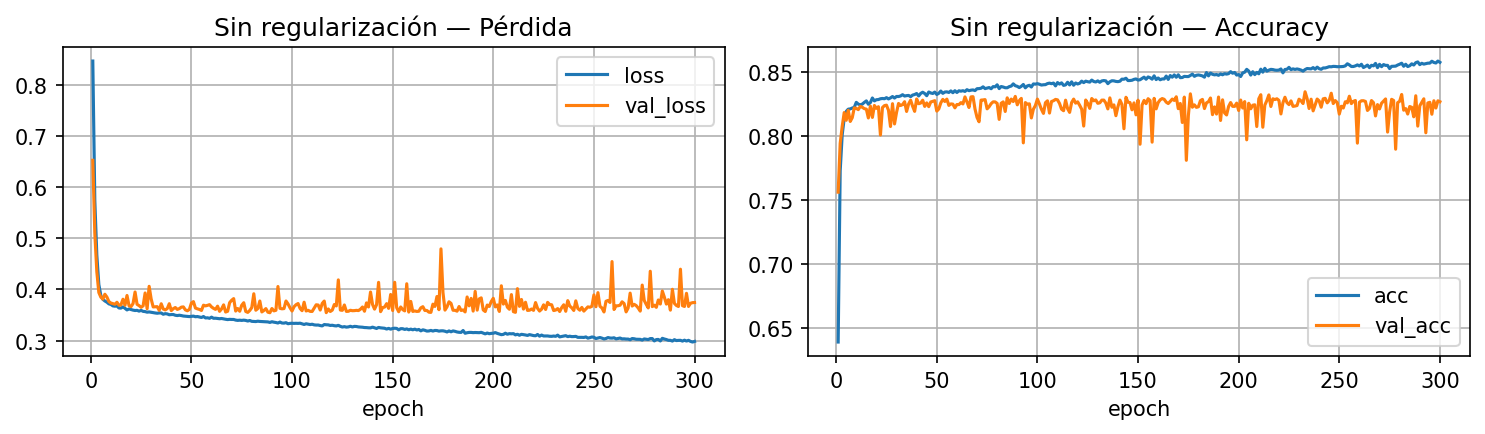

In [13]:

fig = plt.figure(dpi=150, figsize=(10, 3))
ax  = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Sin regularización — Pérdida')
ax  = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Sin regularización — Accuracy')
plt.tight_layout()
plt.show()

Parece no haber overfitting se tiene un accurancy de 84% en los datos de entrenamiento y 83% en los datos de validación

---
## 15. Dropout + L2 + Early Stopping — modelo final

Se combinan las 3 técnicas de regularización.

In [14]:
model = build_model(D_in=12, H=64, D_out=3, p=0.3)   # con Dropout p=0.3
hist  = fit(model, dataloader, epochs=500, log_each=50,
            weight_decay=0.01, early_stopping=30)

Mejor modelo guardado con acc 0.70523 en epoch 1
Mejor modelo guardado con acc 0.76024 en epoch 2
Mejor modelo guardado con acc 0.79379 en epoch 3
Mejor modelo guardado con acc 0.79920 en epoch 4
Mejor modelo guardado con acc 0.80457 en epoch 5
Mejor modelo guardado con acc 0.80925 en epoch 6
Mejor modelo guardado con acc 0.81153 en epoch 7
Mejor modelo guardado con acc 0.81316 en epoch 8
Mejor modelo guardado con acc 0.81394 en epoch 9
Mejor modelo guardado con acc 0.81607 en epoch 10
Mejor modelo guardado con acc 0.81705 en epoch 16
Mejor modelo guardado con acc 0.81777 en epoch 17
Mejor modelo guardado con acc 0.81918 en epoch 27
Epoch 50/500 loss 0.41308 acc 0.81723 val_loss 0.39563 val_acc 0.81725
Mejor modelo guardado con acc 0.81985 en epoch 55
Entrenamiento detenido en epoch 85 por no mejorar en 30 epochs seguidas


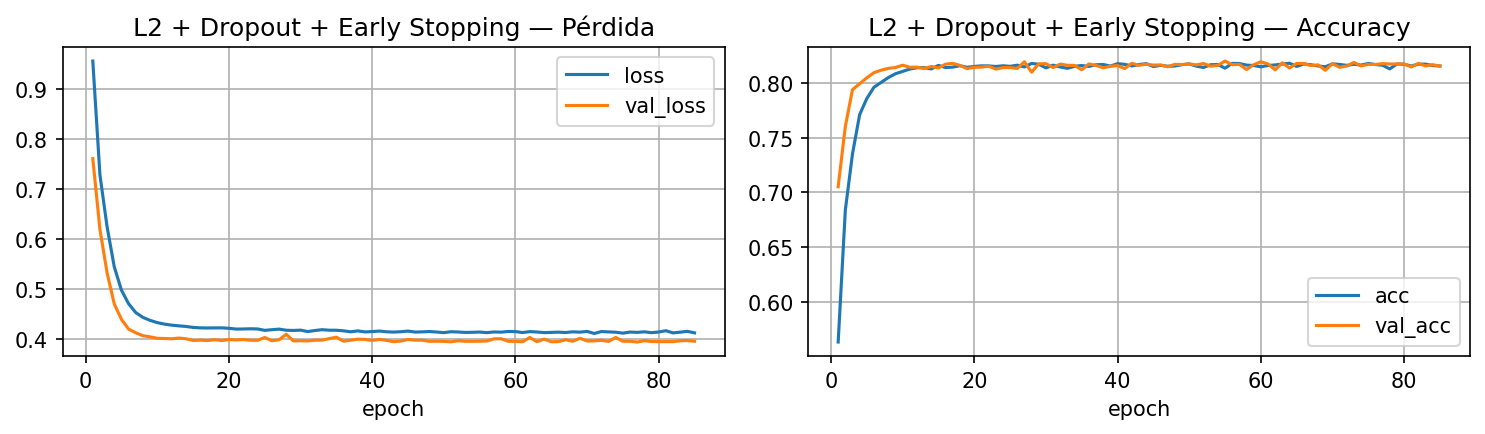

In [15]:
fig = plt.figure(dpi=150, figsize=(10, 3))
ax  = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('L2 + Dropout + Early Stopping — Pérdida')
ax  = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('L2 + Dropout + Early Stopping — Accuracy')
plt.tight_layout()
plt.show()

La precision es mejor con el modelo sin regularizar, así que volvemos a ese modelo

In [16]:
model = build_model(D_in=12, H=64, D_out=3, p=0)
hist  = fit(model, dataloader, epochs=300, log_each=50,
            weight_decay=0, early_stopping=0)

Mejor modelo guardado con acc 0.76242 en epoch 1
Mejor modelo guardado con acc 0.79152 en epoch 2
Mejor modelo guardado con acc 0.80029 en epoch 3
Mejor modelo guardado con acc 0.81511 en epoch 4
Mejor modelo guardado con acc 0.81830 en epoch 5
Mejor modelo guardado con acc 0.82407 en epoch 7
Mejor modelo guardado con acc 0.82410 en epoch 10
Mejor modelo guardado con acc 0.82483 en epoch 17
Mejor modelo guardado con acc 0.82705 en epoch 40
Mejor modelo guardado con acc 0.82739 en epoch 41
Mejor modelo guardado con acc 0.82766 en epoch 49
Epoch 50/300 loss 0.34687 acc 0.83456 val_loss 0.36131 val_acc 0.82701
Mejor modelo guardado con acc 0.82896 en epoch 51
Mejor modelo guardado con acc 0.82937 en epoch 79
Mejor modelo guardado con acc 0.82960 en epoch 91
Epoch 100/300 loss 0.33579 acc 0.83905 val_loss 0.37324 val_acc 0.81975
Mejor modelo guardado con acc 0.83035 en epoch 105
Epoch 150/300 loss 0.32690 acc 0.84244 val_loss 0.38407 val_acc 0.80450
Mejor modelo guardado con acc 0.83046 en

---
## 16. Métricas de clasificación

### 16.1 Obtener predicciones

In [17]:
X_val_t = torch.from_numpy(X_val).float().to(device)

model.eval()
with torch.no_grad():
    logits     = model(X_val_t)
    probs      = torch.softmax(logits, dim=1).cpu().numpy()   # probabilidades por clase
    y_pred_val = np.argmax(probs, axis=1)                      # clase predicha

print('Primeras 10 predicciones:', y_pred_val[:10])
print('Primeras 10 reales:      ', y_val[:10])

Primeras 10 predicciones: [0 1 2 2 2 2 0 1 2 2]
Primeras 10 reales:       [0 1 2 2 2 0 0 1 2 2]


### 16.2 Accuracy

In [18]:
# Accuracy manual — igual que el cuadernillo 8
def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)

acc_manual = accuracy(y_pred_val, y_val)
print(f'Accuracy (manual):  {acc_manual:.4f}')

# Accuracy con sklearn
acc_sklearn = accuracy_score(y_val, y_pred_val)
print(f'Accuracy (sklearn): {acc_sklearn:.4f}')

Accuracy (manual):  0.8355
Accuracy (sklearn): 0.8355


### 16.3 Matriz de Confusión

Muestra cuántos ejemplos de cada clase real fueron predichos como cada clase.

Matriz de Confusión (manual):
[[2341    1  176]
 [   1 2053  507]
 [ 285  297 2040]]

Matriz de Confusión (sklearn):
[[2341    1  176]
 [   1 2053  507]
 [ 285  297 2040]]


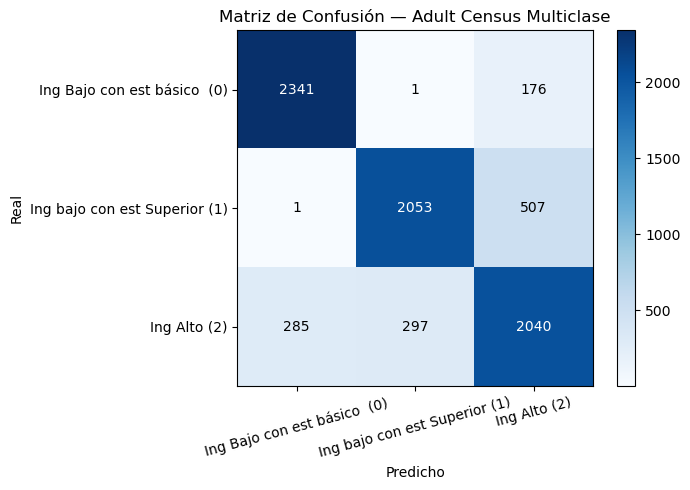

In [19]:
# Matriz de confusión manual
clases     = [0, 1, 2]
etiquetas  = ['Ing Bajo con est básico  (0)', 'Ing bajo con est Superior (1)', 'Ing Alto (2)']
n_clases   = len(clases)
CM_manual  = np.zeros((n_clases, n_clases), dtype=int)

for real, pred in zip(y_val, y_pred_val):
    CM_manual[int(real)][int(pred)] += 1

print('Matriz de Confusión (manual):')
print(CM_manual)

# Matriz de confusión con sklearn
CM_sklearn = confusion_matrix(y_val, y_pred_val)
print('\nMatriz de Confusión (sklearn):')
print(CM_sklearn)

# Visualización
plt.figure(figsize=(7, 5))
plt.imshow(CM_sklearn, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks([0,1,2], etiquetas, rotation=15)
plt.yticks([0,1,2], etiquetas)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión — Adult Census Multiclase')
for i in range(n_clases):
    for j in range(n_clases):
        plt.text(j, i, str(CM_sklearn[i, j]),
                 ha='center', va='center',
                 color='white' if CM_sklearn[i,j] > CM_sklearn.max()/2 else 'black')
plt.tight_layout()
plt.show()

### 16.4 Precision, Recall y F1-Score

Para multiclase se calculan por clase y luego se promedian:
- **macro:** promedio simple entre clases
- **weighted:** promedio ponderado por el número de ejemplos de cada clase

In [20]:
# Precision y Recall manual por clase (One-vs-Rest)
def precision_clase(y_pred, y, clase):
    TP = np.sum((y_pred == clase) & (y == clase))
    FP = np.sum((y_pred == clase) & (y != clase))
    return TP / (TP + FP) if (TP + FP) > 0 else 0

def recall_clase(y_pred, y, clase):
    TP = np.sum((y_pred == clase) & (y == clase))
    FN = np.sum((y_pred != clase) & (y == clase))
    return TP / (TP + FN) if (TP + FN) > 0 else 0

print('Métricas por clase (manual):')
print(f'{"Clase":<15} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-'*47)
for c, et in zip(clases, etiquetas):
    p = precision_clase(y_pred_val, y_val, c)
    r = recall_clase(y_pred_val, y_val, c)
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f'{et:<15} {p:>10.4f} {r:>10.4f} {f:>10.4f}')

# Con sklearn — classification_report
print('\nClassification Report (sklearn):')
print(classification_report(y_val, y_pred_val, target_names=etiquetas))

Métricas por clase (manual):
Clase            Precision     Recall         F1
-----------------------------------------------
Ing Bajo con est básico  (0)     0.8911     0.9297     0.9100
Ing bajo con est Superior (1)     0.8732     0.8016     0.8359
Ing Alto (2)        0.7492     0.7780     0.7633

Classification Report (sklearn):
                               precision    recall  f1-score   support

 Ing Bajo con est básico  (0)       0.89      0.93      0.91      2518
Ing bajo con est Superior (1)       0.87      0.80      0.84      2561
                 Ing Alto (2)       0.75      0.78      0.76      2622

                     accuracy                           0.84      7701
                    macro avg       0.84      0.84      0.84      7701
                 weighted avg       0.84      0.84      0.84      7701



In [21]:
# F1-Score global — macro y weighted
f1_macro    = f1_score(y_val, y_pred_val, average='macro')
f1_weighted = f1_score(y_val, y_pred_val, average='weighted')

print(f'F1-Score macro:    {f1_macro:.4f}')
print(f'F1-Score weighted: {f1_weighted:.4f}')
print()
print('macro    = promedio simple entre clases')
print('weighted = promedio ponderado por cantidad de ejemplos')

F1-Score macro:    0.8364
F1-Score weighted: 0.8354

macro    = promedio simple entre clases
weighted = promedio ponderado por cantidad de ejemplos


### 16.5 Curva ROC — One-vs-Rest para multiclase

Para multiclase, la curva ROC se calcula con el método **One-vs-Rest**: se entrena una curva por cada clase comparándola contra todas las demás.

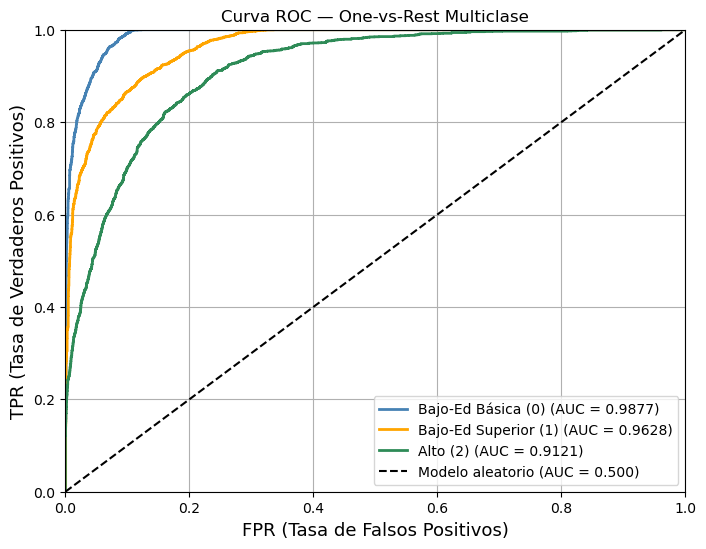

In [27]:

colores = ['steelblue', 'orange', 'seagreen']
etiquetas_clases = ['Bajo-Ed Básica (0)', 'Bajo-Ed Superior (1)', 'Alto (2)']

plt.figure(figsize=(8, 6))

aucs = []
for i, etiqueta in enumerate(etiquetas_clases):
    # Para cada clase: 1 si es esa clase, 0 si es cualquier otra
    y_val_bin = (y_val == i).astype(int)
    fpr, tpr, _ = roc_curve(y_val_bin, probs[:, i])
    auc_score = roc_auc_score(y_val_bin, probs[:, i])
    aucs.append(auc_score)
    plt.plot(fpr, tpr, linewidth=2, color=colores[i], label=f'{etiqueta} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatorio (AUC = 0.500)')
plt.axis([0, 1, 0, 1])
plt.xlabel('FPR (Tasa de Falsos Positivos)', fontsize=13)
plt.ylabel('TPR (Tasa de Verdaderos Positivos)', fontsize=13)
plt.title('Curva ROC — One-vs-Rest Multiclase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

---
## 17. Resumen del modelo

In [23]:
print('='*58)
print('RESUMEN — Adult Census Income (Clasificación Multiclase)')
print('='*58)
print(f'Conversión:        Binario → 3 clases (Bajo/Medio/Alto)')
print(f'Modelo:            MLP PyTorch (2 capas ocultas, H=64)')
print(f'Regularización:    L2 (weight_decay=0.01) + Dropout(p=0.3) + Early Stopping')
print(f'Features (n):      {X_train.shape[1]}')
print(f'Ejemplos train:    {X_train.shape[0]}')
print(f'Ejemplos val:      {X_val.shape[0]}')
print()
print(f'Accuracy:          {acc_sklearn:.4f} ({acc_sklearn*100:.2f}%)')
print(f'F1-Score macro:    {f1_macro:.4f}')
print(f'F1-Score weighted: {f1_weighted:.4f}')
print(f'AUC-ROC macro:     {np.mean(aucs):.4f}')
print()
print('Métricas por clase:')
print(f'{"Clase":<15} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-'*47)
for c, et in zip(clases, etiquetas):
    p = precision_clase(y_pred_val, y_val, c)
    r = recall_clase(y_pred_val, y_val, c)
    f = 2*p*r/(p+r) if (p+r)>0 else 0
    print(f'{et:<15} {p:>10.4f} {r:>10.4f} {f:>10.4f}')
print('='*58)

RESUMEN — Adult Census Income (Clasificación Multiclase)
Conversión:        Binario → 3 clases (Bajo/Medio/Alto)
Modelo:            MLP PyTorch (2 capas ocultas, H=64)
Regularización:    L2 (weight_decay=0.01) + Dropout(p=0.3) + Early Stopping
Features (n):      12
Ejemplos train:    30804
Ejemplos val:      7701

Accuracy:          0.8355 (83.55%)
F1-Score macro:    0.8364
F1-Score weighted: 0.8354
AUC-ROC macro:     0.9542

Métricas por clase:
Clase            Precision     Recall         F1
-----------------------------------------------
Ing Bajo con est básico  (0)     0.8911     0.9297     0.9100
Ing bajo con est Superior (1)     0.8732     0.8016     0.8359
Ing Alto (2)        0.7492     0.7780     0.7633
